# Centralidade de Intermediação

A Centralidade de Intermediação (Betweenness Centrality) mede quantas vezes um nó atua como 'ponte' no menor caminho entre todos os outros pares de nós da rede.

🎯 Aplicação em Auditoria de Contratações:
- Identificação de 'Operadores Centrais' e Laranjas: Pessoas ou Empresas que interligam
  múltiplos grupos que formalmente não deveriam ter relação.
- Escritórios/Contadores em Comum: Entidades que atuam como elo central entre
  empresas concorrentes em licitações públicas.

Usaremos a sua conta gratuita no Neo4J Aura em: https://neo4j.com/cloud/platform/auradb criada no notebook anterior

Copie os dados de conexão utilizados anteriormente na célula abaixo:

In [1]:
import os
from dotenv import load_dotenv

load_dotenv(dotenv_path='.env')

NEO4J_URI=os.getenv("NEO4J_URI")
NEO4J_USERNAME=os.getenv("NEO4J_USERNAME")
NEO4J_DATABASE=os.getenv("NEO4J_DATABASE")
AURA_INSTANCEID=os.getenv("AURA_INSTANCEID")
AURA_INSTANCENAME=os.getenv("AURA_INSTANCENAME")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")


### 1. Instalação do Driver Python para Neo4j

Para interagir com o banco de dados Neo4j a partir do Python, precisamos instalar a biblioteca `neo4j`. O comando `!pip install neo4j` faz essa instalação no ambiente do Colab.

In [2]:
!pip install neo4j

Defaulting to user installation because normal site-packages is not writeable


### 3. Importação de Bibliotecas e Montagem do Google Drive

Esta célula realiza a importação das bibliotecas necessárias (`pandas` para manipulação de dados, `GraphDatabase` do `neo4j` para conexão e `google.colab.drive` para acesso ao Drive). Além disso, monta o seu Google Drive, o que permite que o notebook acesse os arquivos CSV que contêm os dados a serem carregados no grafo. **Lembre-se de ajustar o `CSV_DIR` para o caminho correto onde seus arquivos CSV estão salvos no Drive.**

In [3]:
import pandas as pd
from neo4j import GraphDatabase
#from google.colab import drive
import os

# Montar o Google Drive
#drive.mount('/content/drive')

# ⚠️ AJUSTE AQUI O CAMINHO DA SUA PASTA NO GOOGLE DRIVE
#CSV_DIR = '/content/drive/MyDrive/Aulas/Aulas IDP/2026/Auditoria de Dados e Accountability/modulo IV - Grafos e IA/grafos'

CSV_DIR = './grafos'

print("Conteúdo da pasta de CSVs:")
if os.path.exists(CSV_DIR):
    print(os.listdir(CSV_DIR))
else:
    print(f"⚠️ Atenção: A pasta '{CSV_DIR}' ainda não existe no seu Google Drive. Verifique o caminho!")

Conteúdo da pasta de CSVs:
['relacao_socios.csv', 'relacao_pai_filho.csv', 'orgaos_ficticios.csv', 'licitacoes.csv', 'pessoas_ficticias.csv', 'relacao_mae_filho.csv', 'participantes_licitacao.csv', 'empresas_ficticias.csv', 'relacao_pregoeiros.csv']


Testando a instância

### 4. Teste de Conexão

Este bloco de código estabelece uma conexão inicial com o banco de dados Neo4j usando as credenciais fornecidas. A linha `driver.verify_connectivity()` confirma se a conexão foi bem-sucedida.

Verifique no Neo4J Aura Bloom o estado do seu grafo

In [4]:
with GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME,NEO4J_PASSWORD)) as driver:

    driver.verify_connectivity()



### 5. Criação da Classe `Neo4jConn` para Interação com o Banco de Dados

Para facilitar a interação com o Neo4j, criamos uma classe `Neo4jConn`. Ela encapsula a lógica de conexão (`__init__`) e o método `query` para executar comandos Cypher. Isso torna o código mais organizado e reutilizável. O teste de conexão final verifica se a classe consegue se comunicar e obter a versão do Neo4j.

In [5]:
class Neo4jConn:
    def __init__(self, uri, user, password):
        self.driver = GraphDatabase.driver(uri, auth=(user, password))

    def close(self):
        self.driver.close()

    def query(self, query_str, parameters=None):
        with self.driver.session() as session:
            result = session.run(query_str, parameters or {})
            return [record.data() for record in result]

# Teste de Conexão
db = Neo4jConn(NEO4J_URI, NEO4J_USERNAME, NEO4J_PASSWORD)
print("Conexão bem-sucedida! Versão do Neo4j:", db.query("CALL dbms.components() YIELD name, versions, edition WHERE name = 'Neo4j Kernel' RETURN versions[0] AS neo4jVersion"))

Conexão bem-sucedida! Versão do Neo4j: [{'neo4jVersion': '5.27-aura'}]


### 6. CARGA DE CONTADORES E PRESTAÇÃO DE SERVIÇO

#### 6.1 Restrições
Vamos criar as restrições para os novos nós de contadores.

In [6]:
db.query("CREATE CONSTRAINT IF NOT EXISTS FOR (c:Contador) REQUIRE c.registro_crc IS UNIQUE;")

print("Restrições de unicidade criadas com sucesso!")

Restrições de unicidade criadas com sucesso!


#### 6.2. Carga dos Nós (Entidades)

Nesta etapa, carregamos os dados do arquivo CSV para criar os nós de contadores e sua relação com pessoa física

In [8]:
df_contadores = pd.read_csv(os.path.join(CSV_DIR, "contadores_ficticios.csv"))

q_contadores = """
UNWIND $rows AS row
MERGE (c:Contador {registro_crc: row.registro_crc})
SET c.uf_crc = row.uf_crc,
    c.nome_contador = row.nome_contador
WITH c, row
MATCH (p:Pessoa {cpf: row.cpf_contador})
MERGE (p)-[:E_CONTADOR]->(c)
"""
db.query(q_contadores, {"rows": df_contadores.to_dict('records')})
print(f"✓ Contadores carregados e vinculados às Pessoas: {len(df_contadores)}")


✓ Contadores carregados e vinculados às Pessoas: 15


### 6.3 Carga dos Relacionamentos (Arestas)

Carregar Relação: PRESTA_SERVICO_PARA (Contador -> Empresa)

In [10]:
df_rel_contador = pd.read_csv(os.path.join(CSV_DIR, "relacao_contador_empresa.csv"))

q_rel_contador = """
UNWIND $rows AS row
MATCH (c:Contador {registro_crc: row.registro_crc})
MATCH (e:Empresa {cnpj: row.cnpj_empresa})
MERGE (c)-[r:PRESTA_SERVICO_PARA]->(e)
SET r.data_inicio_prestacao = row.data_inicio_prestacao
"""
db.query(q_rel_contador, {"rows": df_rel_contador.to_dict('records')})
print(f"✓ Vínculos de prestação de serviços contábeis criados: {len(df_rel_contador)}")

✓ Vínculos de prestação de serviços contábeis criados: 50


### 7. Criação da Projeção de Grafo no Neo4j GDS (In-Memory Graph)
Para executar algoritmos como o Betweenness Centrality no Neo4j, primeiro projetamos o subgrafo relevante na memória usando o módulo GDS (Graph Data Science).

#### 7.1 Limpar projeção anterior se existir

In [11]:
db.query("CALL gds.graph.drop('grafo-auditoria', false)")

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "CALL gds.graph.drop('grafo-auditoria', false)"


[]

#### 7.2 Criar a projeção não-direcionada envolvendo Pessoas, Empresas e Órgãos

**O que é uma Projeção de Grafo?**

Uma projeção de grafo é a criação de um subgrafo em memória (ou seja, uma representação temporária do grafo) a partir de um grafo maior armazenado no banco de dados. Isso é feito para otimizar a execução de algoritmos de grafo (como o Betweenness Centrality).

Ao invés de carregar o grafo inteiro, selecionamos apenas os tipos de nós e relacionamentos relevantes para a análise. Isso economiza memória, melhora a performance e evita que o algoritmo processe dados desnecessários. A projeção `grafo-auditoria` que criamos inclui  `Empresas`, `Orgãos`, `Licitações` e `Contadores`, e os tipos de relacionamentos específicos que nos interessam.

In [12]:
cypher_projection = """
CALL gds.graph.project(
  'grafo-auditoria',
  ['Empresa', 'Orgao', 'Licitacao', 'Contador'],
  ['PRESTA_SERVICO_PARA', 'PROMOVIDA_POR', 'PARTICIPOU_DE'],
  { memory: '2GB' }
)
YIELD graphName, nodeCount, relationshipCount
"""

res_proj = db.query(cypher_projection)
print(f"✓ Projeção '{res_proj[0]['graphName']}' criada com {res_proj[0]['nodeCount']} nós e {res_proj[0]['relationshipCount']} relações!")

✓ Projeção 'grafo-auditoria' criada com 145 nós e 319 relações!


### 8. Executar o Betweenness Centrality

In [13]:
cypher_betweenness_contadores = """
CALL gds.betweenness.stream('grafo-auditoria')
YIELD nodeId, score
WITH gds.util.asNode(nodeId) AS node, score
WHERE score > 0
RETURN
    labels(node)[0] AS TipoEntidade,
    coalesce(node.nome_contador, node.nome, node.razao_social, node.nome_orgao, node.codigo_licitacao) AS Nome,
    coalesce(node.registro_crc, node.cpf, node.cnpj, node.codigo_orgao, node.codigo_licitacao) AS Identificador,
    score AS BetweennessScore
ORDER BY BetweennessScore DESC
LIMIT 15
"""

res_betweenness = db.query(cypher_betweenness_contadores)
df_res = pd.DataFrame(res_betweenness)
print("🏆 Top 15 Entidades Centrais (Incluindo Contadores em Comum):")
df_res

🏆 Top 15 Entidades Centrais (Incluindo Contadores em Comum):


,TipoEntidade,Nome,Identificador,BetweennessScore
0,Empresa,Brasil Comércio EPP,71.331.509/0001-65,16.833333
1,Empresa,Pinnacle Saneamento e Serviços ME,89.638.346/0001-23,12.000000
2,Empresa,Apex Transportes Ltda.,94.026.542/0001-87,10.233333
3,Licitacao,LIC-2024-0024,LIC-2024-0024,10.000000
4,Empresa,Inova Sistemas ME,02.563.421/0001-56,9.500000
5,Licitacao,LIC-2024-0013,LIC-2024-0013,9.000000
6,Empresa,Horizonte Comunicação e Serviços S.A.,12.411.824/0001-33,9.000000
7,Licitacao,LIC-2024-0041,LIC-2024-0041,9.000000
8,Empresa,Max Empreendimentos e Serviços S.A.,45.868.501/0001-22,8.950000
9,Empresa,Vortex Transportes e Serviços Eireli,87.347.143/0001-52,8.750000


### 9. Visualizar Relações da Entidade com Maior Betweenness Centrality

Vamos agora inspecionar as relações da entidade que obteve a maior pontuação de Betweenness Centrality,  `Brasil Comércio EPP` (CNPJ `71.331.509/0001-65`). Isso nos ajudará a entender o papel de 'ponte' que essa entidade desempenha no grafo.

In [15]:
cypher_central_node_relations = """
MATCH (e:Empresa {cnpj: '71.331.509/0001-65'})-[r]-(target)
RETURN e.razao_social AS EmpresaCentral,
       type(r) AS TipoRelacao,
       labels(target)[0] AS TipoEntidadeAlvo,
       coalesce(target.nome_contador, target.nome, target.codigo_licitacao, target.razao_social, target.nome_orgao) AS NomeEntidadeAlvo,
       coalesce(target.registro_crc, target.cpf, target.cnpj, target.codigo_orgao) AS IdentificadorEntidadeAlvo
"""

res_central_relations = db.query(cypher_central_node_relations)
df_central_relations = pd.DataFrame(res_central_relations)

print(f"Relações do nó central : {len(df_central_relations)}")
display(df_central_relations)

Relações do nó central : 12


,EmpresaCentral,TipoRelacao,TipoEntidadeAlvo,NomeEntidadeAlvo,IdentificadorEntidadeAlvo
0,Brasil Comércio EPP,E_SOCIO_DE,Pessoa,Juliana Martins Vieira,606.474.687-43
1,Brasil Comércio EPP,E_SOCIO_DE,Pessoa,Leticia Mendes Andrade,024.026.811-36
2,Brasil Comércio EPP,PARTICIPOU_DE,Licitacao,LIC-2024-0018,None
3,Brasil Comércio EPP,PARTICIPOU_DE,Licitacao,LIC-2024-0021,None
4,Brasil Comércio EPP,PARTICIPOU_DE,Licitacao,LIC-2024-0023,None
5,Brasil Comércio EPP,PARTICIPOU_DE,Licitacao,LIC-2024-0024,None
6,Brasil Comércio EPP,PARTICIPOU_DE,Licitacao,LIC-2024-0032,None
7,Brasil Comércio EPP,PARTICIPOU_DE,Licitacao,LIC-2024-0036,None
8,Brasil Comércio EPP,PARTICIPOU_DE,Licitacao,LIC-2024-0043,None
9,Brasil Comércio EPP,PARTICIPOU_DE,Licitacao,LIC-2024-0044,None


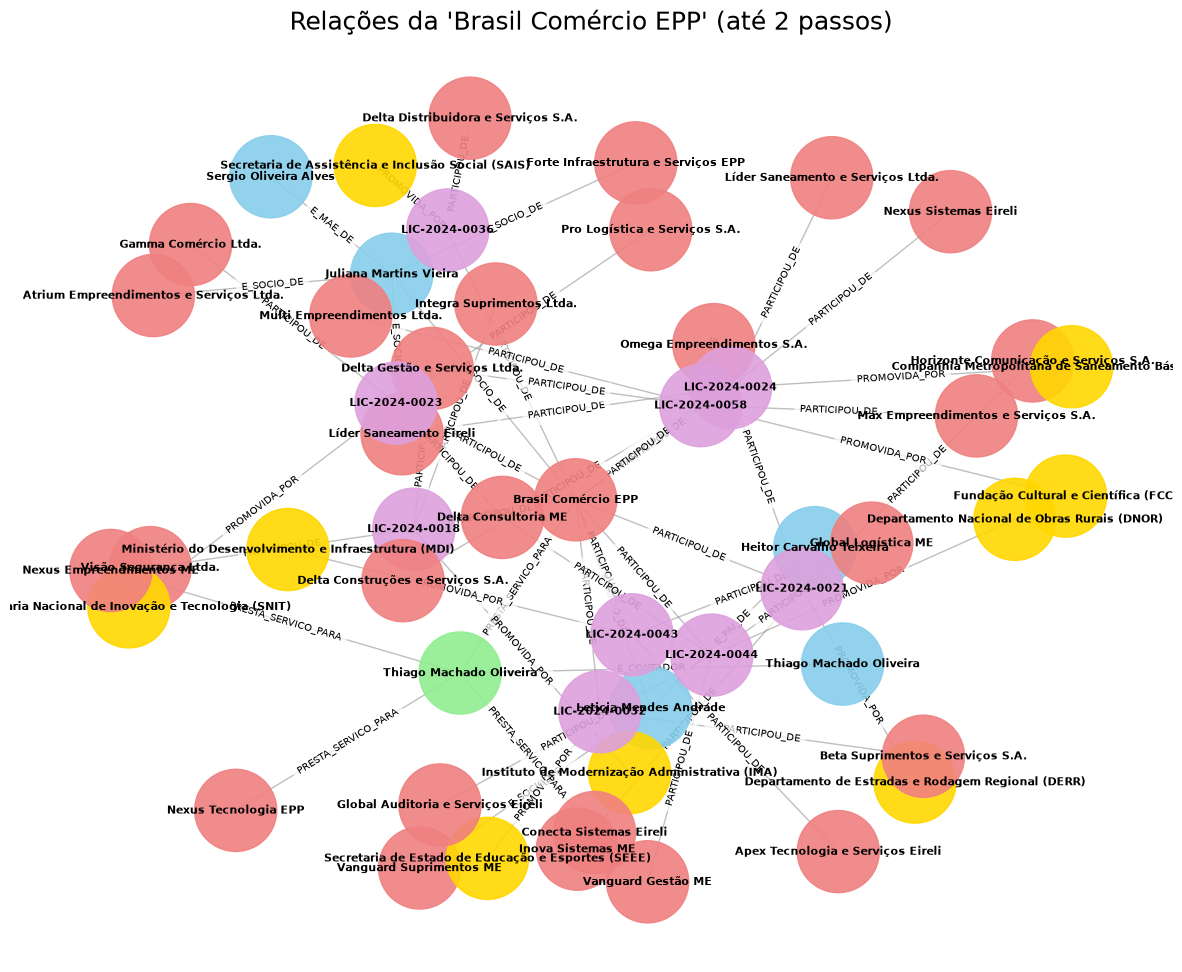

In [16]:
import networkx as nx
import matplotlib.pyplot as plt

# Cypher query to get the central node and its connections up to 2 steps
cypher_graph_data_2_steps = """
MATCH path = (e:Empresa {cnpj: '71.331.509/0001-65'})-[r*1..2]-(target)
UNWIND relationships(path) AS rel
WITH DISTINCT rel
RETURN
    coalesce(startNode(rel).nome_contador, startNode(rel).nome, startNode(rel).razao_social, startNode(rel).nome_orgao, startNode(rel).codigo_licitacao) AS sourceName,
    labels(startNode(rel))[0] AS sourceType,
    type(rel) AS relationshipType,
    coalesce(endNode(rel).nome_contador, endNode(rel).nome, endNode(rel).razao_social, endNode(rel).nome_orgao, endNode(rel).codigo_licitacao) AS targetName,
    labels(endNode(rel))[0] AS targetType,
    coalesce(startNode(rel).cpf, startNode(rel).cnpj, startNode(rel).registro_crc, startNode(rel).codigo_orgao, elementId(startNode(rel))) AS sourceId,
    coalesce(endNode(rel).cpf, endNode(rel).cnpj, endNode(rel).registro_crc, endNode(rel).codigo_orgao, elementId(endNode(rel))) AS targetId
"""

graph_data_2_steps = db.query(cypher_graph_data_2_steps)

# Create a NetworkX graph
G_2_steps = nx.Graph()

# Add nodes and edges
for row in graph_data_2_steps:
    # Add source node
    G_2_steps.add_node(row['sourceId'], label=row['sourceName'], type=row['sourceType'])
    # Add target node
    G_2_steps.add_node(row['targetId'], label=row['targetName'], type=row['targetType'])
    # Add edge
    G_2_steps.add_edge(row['sourceId'], row['targetId'], relationship=row['relationshipType'])

# Set node colors based on type
node_colors_2_steps = []
node_labels_2_steps = {}
# Reuse the existing color_map or define it if not available globally
color_map = {
    'Pessoa': 'skyblue',
    'Empresa': 'lightcoral',
    'Contador': 'lightgreen',
    'Orgao': 'gold',
    'Licitacao': 'plum'
}

for node in G_2_steps.nodes():
    node_type = G_2_steps.nodes[node].get('type', 'unknown')
    node_colors_2_steps.append(color_map.get(node_type, 'gray'))
    node_labels_2_steps[node] = G_2_steps.nodes[node].get('label', node) # Use the 'label' attribute for display

# Set edge labels
edge_labels_2_steps = nx.get_edge_attributes(G_2_steps, 'relationship')

# Draw the graph
plt.figure(figsize=(15, 12))
pos_2_steps = nx.spring_layout(G_2_steps, k=0.7, iterations=50, seed=42)  # Use spring layout for better visualization, added seed for reproducibility
nx.draw_networkx_nodes(G_2_steps, pos_2_steps, node_color=node_colors_2_steps, node_size=3500, alpha=0.9)
nx.draw_networkx_edges(G_2_steps, pos_2_steps, width=1.0, alpha=0.5, edge_color='gray')
nx.draw_networkx_labels(G_2_steps, pos_2_steps, labels=node_labels_2_steps, font_size=8, font_weight='bold')
nx.draw_networkx_edge_labels(G_2_steps, pos_2_steps, edge_labels=edge_labels_2_steps, font_size=7, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.title("Relações da 'Brasil Comércio EPP' (até 2 passos)", size=18)
plt.axis('off') # Hide axes
plt.show()

In [18]:
%pip install pyvis

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [19]:
from pyvis.network import Network

# Create a Pyvis network object
net = Network(notebook=True, height='750px', width='100%', cdn_resources='remote')

# Add nodes and edges from the NetworkX graph
# Using the G_2_steps graph created previously
for node in G_2_steps.nodes(data=True):
    node_id = node[0]
    node_attrs = node[1]
    net.add_node(node_id, label=node_attrs.get('label', node_id), title=node_attrs.get('label', node_id), group=node_attrs.get('type', 'unknown'))

for edge in G_2_steps.edges(data=True):
    source = edge[0]
    target = edge[1]
    edge_attrs = edge[2]
    net.add_edge(source, target, title=edge_attrs.get('relationship', 'rel'))

# Configure physics and interaction for better usability
net.show_buttons(filter_=['physics', 'nodes', 'edges'])

# Save the network to an HTML file and display it
# You can open the HTML file in a web browser to interact with it
net.save_graph('interactive_graph.html')


In [21]:
%pip install IPython

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [23]:
from IPython.display import display, HTML

display(HTML(filename='interactive_graph.html'))

Cole essa query no Neo4J:
```cypher
MATCH (e:Empresa)-[r*1..2]-(target)
WHERE e.cnpj = '71.331.509/0001-65'
RETURN e, r, target
```